In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
import pickle 
import tqdm
import json 
import copy
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib import colors
import torchvision
import torch.nn.functional as F
import pandas as pd
import pprint
import wandb


In [2]:

path =  '../data/results/sequence_length.pkl'



objects = []
with (open(path, "rb")) as openfile:
    while True:
        try:
            objects.append(pickle.load(openfile))
        except EOFError:
            break

In [3]:
metrics = objects[-1]


In [4]:
import wandb

api = wandb.Api()

run_ids = list(metrics.keys())
project = "RETRACTED"  

configs = {}

for run_id in run_ids:
    run = api.run(f"{project}/{run_id}")
    configs[run_id] = run.config

    #print(configs[run_id]['inputs'])

In [5]:
len(metrics)

28

In [6]:
group_by = "train_period" # inputs['input_seq_len']


grouped = {}   # {inputs_key: {metric_name: [values]} }

for run_id, run_data in metrics.items():

    run = api.run(f"{project}/{run_id}")
    inputs = run.config.get(group_by)['input_seq_len']

    # make inputs usable as dict key
    if isinstance(inputs, list):
        inputs_key = tuple(inputs)
    else:
        inputs_key = inputs

    if inputs_key not in grouped:
        grouped[inputs_key] = {}

    m = run_data["val"][list(run_data["val"].keys())[0]]

    for k, v in m.items():
        if torch.is_tensor(v):
            v = v.item()
        if not isinstance(v, (int, float)):
            continue

        grouped[inputs_key].setdefault(k, []).append(v)

stats = {}   # {inputs_key: {metric: (mean, std)}}

for inputs_key, metric_dict in grouped.items():
    stats[inputs_key] = {}
    for metric, values in metric_dict.items():
        if len(values) >= 1:
            mean = np.mean(values)
            std = np.std(values, ddof=1) if len(values) > 1 else 0.0
            stats[inputs_key][metric] = (mean, std)

for inputs_key, metric_stats in stats.items():
    print(f"\n=== seq_len = {inputs_key} ===")
    for metric, (mean, std) in metric_stats.items():
        print(f"{metric}: mean={mean:.3f}, std={std:.3f}")



=== seq_len = 8 ===
val_iou: mean=0.287, std=0.007
val_f1: mean=0.445, std=0.009
val_precision: mean=0.473, std=0.014
val_recall: mean=0.421, std=0.010
val_average_precision: mean=0.428, std=0.006
val_ROC_AUC: mean=0.901, std=0.001
val_MAE: mean=32.872, std=0.887
val_MSE: mean=9494.382, std=1138.111
val_PearsonR: mean=0.593, std=0.062
val_R2: mean=0.342, std=0.079
val_RMSE: mean=97.300, std=6.003
val_loss: mean=0.436, std=0.003

=== seq_len = 2 ===
val_iou: mean=0.263, std=0.007
val_f1: mean=0.416, std=0.009
val_precision: mean=0.443, std=0.014
val_recall: mean=0.393, std=0.017
val_average_precision: mean=0.391, std=0.011
val_ROC_AUC: mean=0.881, std=0.010
val_MAE: mean=34.882, std=1.125
val_MSE: mean=11540.682, std=856.654
val_PearsonR: mean=0.489, std=0.046
val_R2: mean=0.200, std=0.059
val_RMSE: mean=107.373, std=3.961
val_loss: mean=0.457, std=0.008

=== seq_len = 3 ===
val_iou: mean=0.273, std=0.004
val_f1: mean=0.429, std=0.005
val_precision: mean=0.447, std=0.007
val_recall: me

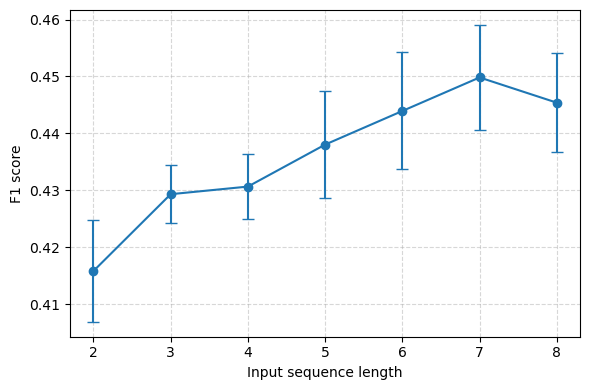

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Extract patch sizes, means, and stds for val_f1
patch_sizes = []
means = []
stds = []

for inputs_key, metric_stats in stats.items():
    if "val_f1" in metric_stats:
        patch_sizes.append(inputs_key)
        m, s = metric_stats["val_f1"]
        means.append(m)
        stds.append(s)

# Sort by patch size if needed
patch_sizes, means, stds = zip(*sorted(zip(patch_sizes, means, stds)))

# Plot
plt.figure(figsize=(6,4))
plt.errorbar(patch_sizes, means, yerr=stds, fmt='o-', capsize=4)
plt.xlabel("Input sequence length")
plt.ylabel("F1 score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


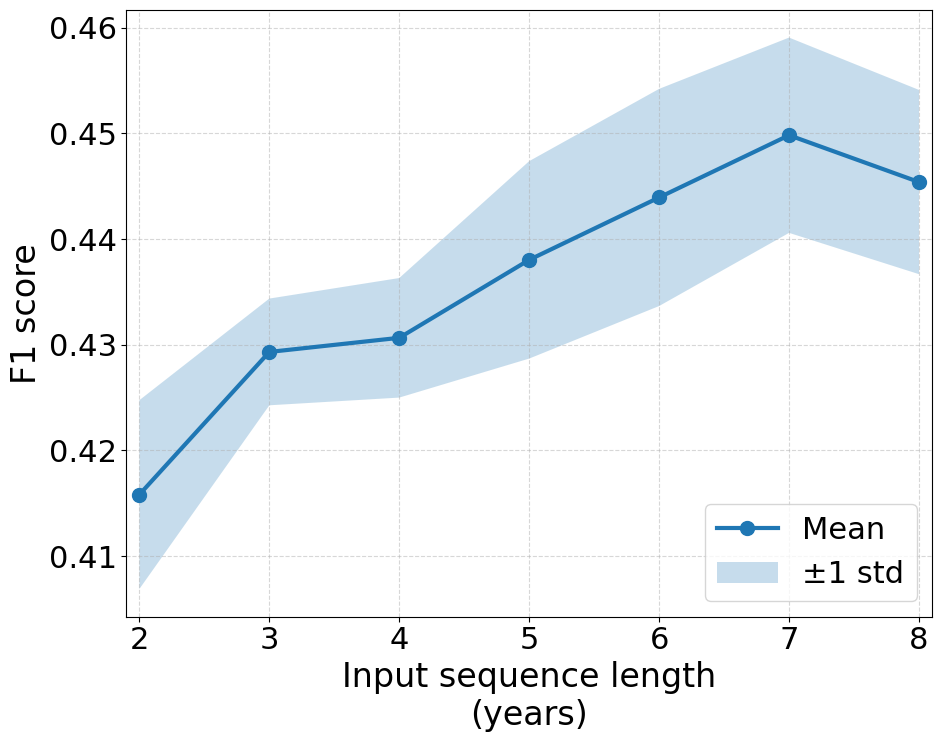

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Extract patch sizes, means, and stds for val_f1
patch_sizes = []
means = []
stds = []


# ---- Global style (publication) ----
plt.rcParams.update({
    "font.size": 26,
    "axes.labelsize": 24,
    "axes.titlesize": 24,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
    "lines.linewidth": 3,
    "lines.markersize": 10,
})

for inputs_key, metric_stats in stats.items():
    if "val_f1" in metric_stats:
        patch_sizes.append(inputs_key)
        m, s = metric_stats["val_f1"]
        means.append(m)
        stds.append(s)

# Sort by patch size
patch_sizes, means, stds = map(
    np.array, zip(*sorted(zip(patch_sizes, means, stds)))
)

# Plot
plt.figure(figsize=(10, 8))

plt.plot(
    patch_sizes,
    means,
    marker="o",
    #color='black',
    label="Mean",
)

plt.fill_between(
    patch_sizes,
    means - stds,
    means + stds,
    #color="black",
    alpha=0.25,
    label="±1 std",
)

plt.xlim(1.9, 8.1)



plt.xlabel("Input sequence length\n(years)")

plt.ylabel("F1 score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("seq_len.pdf", bbox_inches="tight")

